# Day 08. Exercise 03
# Overfitting

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

## 1. Preprocessing

In [2]:
df = pd.read_csv('../data/dayofweek.csv')
X = df.drop('dayofweek', axis=1).values
y = df['dayofweek'].values
print('Shape:', df.shape)

Shape: (1686, 44)


In [3]:
# Split without stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)
print('Train distribution:')
print(pd.Series(y_train).value_counts(normalize=True))
print('\nTest distribution:')
print(pd.Series(y_test).value_counts(normalize=True))

Train distribution:
3    0.232196
6    0.212908
1    0.164688
5    0.160237
2    0.092730
0    0.077893
4    0.059347
Name: proportion, dtype: float64

Test distribution:
3    0.245562
6    0.204142
5    0.162722
1    0.153846
0    0.091716
4    0.071006
2    0.071006
Name: proportion, dtype: float64


In [4]:
# Split WITH stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21, stratify=y
)
print('Train distribution (stratified):')
print(pd.Series(y_train).value_counts(normalize=True))
print('\nTest distribution (stratified):')
print(pd.Series(y_test).value_counts(normalize=True))

Train distribution (stratified):
3    0.234421
6    0.211424
1    0.162463
5    0.160979
2    0.088279
0    0.080861
4    0.061573
Name: proportion, dtype: float64

Test distribution (stratified):
3    0.236686
6    0.210059
1    0.162722
5    0.159763
2    0.088757
0    0.079882
4    0.062130
Name: proportion, dtype: float64


## 2. Baseline models

### a. Logreg

In [5]:
logreg = LogisticRegression(random_state=21, fit_intercept=False, max_iter=1000)
logreg.fit(X_train, y_train)
acc = accuracy_score(y_test, logreg.predict(X_test))
print(f'Logreg accuracy on test: {acc:.4f}')

Logreg accuracy on test: 0.6331


### b. SVM

In [6]:
svm = SVC(kernel='linear', probability=True, random_state=21)
svm.fit(X_train, y_train)
acc = accuracy_score(y_test, svm.predict(X_test))
print(f'SVM accuracy on test: {acc:.4f}')

SVM accuracy on test: 0.7160


### c. Decision tree

In [7]:
tree = DecisionTreeClassifier(max_depth=4, random_state=21)
tree.fit(X_train, y_train)
acc = accuracy_score(y_test, tree.predict(X_test))
print(f'Decision Tree accuracy on test: {acc:.4f}')

Decision Tree accuracy on test: 0.5296


### d. Random forest

In [8]:
rf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rf.fit(X_train, y_train)
acc = accuracy_score(y_test, rf.predict(X_test))
print(f'Random Forest accuracy on test: {acc:.4f}')

Random Forest accuracy on test: 0.9349


Random Forest has the largest difference compared to Ex02 because it was overfitting before — it memorized training data.

## 3. Crossvalidation

### a. Logreg

In [9]:
logreg_cv = LogisticRegression(solver='liblinear', random_state=21, fit_intercept=False)
scores = cross_val_score(logreg_cv, X_train, y_train, cv=10)
print(f'Logreg CV mean: {scores.mean():.4f}, std: {scores.std():.4f}')

Logreg CV mean: 0.5816, std: 0.0253


### b. SVM

In [10]:
svm_cv = SVC(kernel='linear', probability=True, random_state=21)
scores = cross_val_score(svm_cv, X_train, y_train, cv=10)
print(f'SVM CV mean: {scores.mean():.4f}, std: {scores.std():.4f}')

SVM CV mean: 0.6587, std: 0.0436


### c. Decision tree

In [11]:
tree_cv = DecisionTreeClassifier(max_depth=4, random_state=21)
scores = cross_val_score(tree_cv, X_train, y_train, cv=10)
print(f'Decision Tree CV mean: {scores.mean():.4f}, std: {scores.std():.4f}')

Decision Tree CV mean: 0.5089, std: 0.0319


### d. Random forest

In [12]:
rf_cv = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
scores = cross_val_score(rf_cv, X_train, y_train, cv=10)
print(f'Random Forest CV mean: {scores.mean():.4f}, std: {scores.std():.4f}')

Random Forest CV mean: 0.9125, std: 0.0175


## 4. Optimization

In [13]:
# Best model: Random Forest with tuned params
best_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=21)
scores = cross_val_score(best_model, X_train, y_train, cv=10)
print(f'Tuned RF CV mean: {scores.mean():.4f}, std: {scores.std():.4f}')

Tuned RF CV mean: 0.9110, std: 0.0191


In [14]:
# Final accuracy on test
best_model.fit(X_train, y_train)
acc = accuracy_score(y_test, best_model.predict(X_test))
print(f'Final model accuracy on test: {acc:.4f}')

Final model accuracy on test: 0.9231


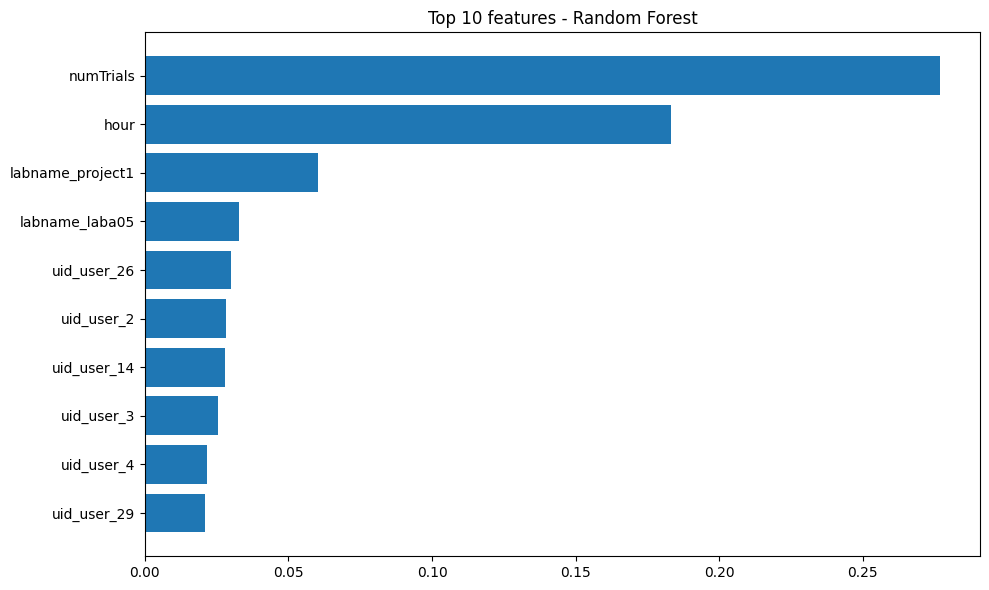

In [15]:
# Top 10 features
feature_names = df.drop('dayofweek', axis=1).columns
importance = best_model.feature_importances_
idx = np.argsort(importance)[-10:]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(np.array(feature_names)[idx], importance[idx])
ax.set_title('Top 10 features - Random Forest')
plt.tight_layout()
plt.show()

In [16]:
# Save model
joblib.dump(best_model, '../data/best_model.joblib')
print('Model saved')

Model saved


In [17]:
# Load and predict
loaded_model = joblib.load('../data/best_model.joblib')
acc = accuracy_score(y_test, loaded_model.predict(X_test))
print(f'Loaded model accuracy: {acc:.4f}')

Loaded model accuracy: 0.9231
